# Recommender Systems - Collaborative Filtering - Task1

### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
import random
import time

In [ ]:
cols = ["user", "item", "rating", "timestamp"]
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_recommender_task1/u.data", sep="\t", names=cols)

In [ ]:
df.head()

,user,item,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user       100000 non-null  int64
 1   item       100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [ ]:
df["user"].nunique()

943

In [ ]:
df.duplicated().sum()

np.int64(0)

## Data Split

In [ ]:
df["u"] = df["user"].astype("category").cat.codes
df["m"] = df["item"].astype("category").cat.codes
n_users, n_movies = df["u"].nunique(), df["m"].nunique()

In [ ]:
def per_user_split(df, test_frac=0.2, val_frac=0.1, seed=42):
    df = df.sample(frac=1, random_state=seed)          # shuffle once
    rank = df.groupby("u").cumcount()                  # 0,1,2,... within each user
    size = df.groupby("u")["u"].transform("size")
    frac = rank / size                                 # position as a fraction 0..1
    test  = df[frac < test_frac]
    val   = df[(frac >= test_frac) & (frac < test_frac + val_frac)]
    train = df[frac >= test_frac + val_frac]
    return train, val, test

train_df, val_df, test_df = per_user_split(df)
print(len(train_df), len(val_df), len(test_df))

69475 10144 20381


In [ ]:
train_df.head()

,user,item,rating,timestamp,u,m
47158,728,282,4,879443291,727,281
58771,856,258,4,891489356,855,257
68644,856,750,5,891489250,855,749
8131,153,127,3,881371140,152,126
16787,288,357,5,886373591,287,356


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69475 entries, 47158 to 15795
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user       69475 non-null  int64
 1   item       69475 non-null  int64
 2   rating     69475 non-null  int64
 3   timestamp  69475 non-null  int64
 4   u          69475 non-null  int16
 5   m          69475 non-null  int16
dtypes: int16(2), int64(4)
memory usage: 2.9 MB


In [ ]:
train_df["user"].nunique()

943

In [ ]:
test_df["user"].nunique()

943

In [ ]:
train_df["item"].nunique()

1630

In [ ]:
n_movies

1682

In [ ]:
print(train_df.isna().sum())
print("duplicate (user,item) pairs:", train_df.duplicated(["user", "item"]).sum())
print("rating values:", sorted(train_df["rating"].unique()))
print("min ratings per user:", train_df.groupby("user").size().min())
print(train_df.groupby("item").size().describe())

user         0
item         0
rating       0
timestamp    0
u            0
m            0
dtype: int64
duplicate (user,item) pairs: 0
rating values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
min ratings per user: 13
count    1630.000000
mean       42.622699
std        56.315721
min         1.000000
25%         5.000000
50%        20.000000
75%        56.000000
max       380.000000
dtype: float64


# Memory Based KNN recommender system

## User-item Matrix creator

In [ ]:
def create_R(df,n_users,n_movies):
  R=np.zeros((n_users,n_movies))
  R[df["u"],df["m"]]=df["rating"]
  mask=R>0
  sparsity=mask.mean()
  print("Sparsity:",(1-sparsity)*100,"%")
  return R,mask

In [ ]:
R_train,mask=create_R(train_df,n_users,n_movies)


Sparsity: 95.619830959205 %


In [ ]:
counts=mask.sum(axis=1)
user_mean=R_train.sum(axis=1)/np.maximum(counts,1)
R_train_centre=(R_train-user_mean[:,None])*mask

In [ ]:
# checking if values are correct
print("all rows add to zero : ",np.round(R_train_centre.sum(axis=1).max())==0)
print("All masked values are zero: ",R_train_centre[mask==0].max()==0)

all rows add to zero :  True
All masked values are zero:  True


In [ ]:
dot=R_train_centre @ R_train_centre.T
norms=np.linalg.norm(R_train_centre,axis=1)
S=dot/(np.outer(norms,norms)+1e-9)
np.fill_diagonal(S,0)

In [ ]:
# Sanity check
print("S size:",S.shape)
print("S max:",S.max())
print("S min:",S.min())
print("")

S size: (943, 943)
S max: 0.5793719032390141
S min: -0.49176311688119145



## KNN Model

In [ ]:
def predict_user(u, i, k, S, Rc, mask, user_mean):
    V = np.where(mask[:, i])[0]
    if len(V) == 0:
        return user_mean[u]

    sims = S[u, V]
    top = np.argsort(-sims)[:k]
    s = np.clip(sims[top], 0, None)
    r = Rc[V, i][top]

    if s.sum() == 0:
        return user_mean[u]
    pred = user_mean[u] + (s * r).sum() / s.sum()
    return np.clip(pred, 1, 5)

In [ ]:
pred=user_mean[val_df["u"]]
rmse=np.sqrt(np.mean((val_df["rating"].values-pred)**2))
mae=np.mean(np.abs(val_df["rating"].values-np.array(pred)))
print("RMSE Baseline :",rmse)
print("MAE Baseline :",mae)
def eval_rmse(d, k):
    preds = [predict_user(u, i, k, S, R_train_centre, mask, user_mean)
             for u, i in zip(d["u"], d["m"])]
    rmse=np.sqrt(np.mean((d["rating"].values-np.array(preds))**2))
    mae=np.mean(np.abs(d["rating"].values-np.array(preds)))
    return rmse,mae

print("Using the validation set")
k_list=list(range(5,150,5))
loss_list_rmse=[]
loss_list_mae=[]
loss_list_rmse.append(rmse)
loss_list_mae.append(mae)
for k in k_list:
    rmse,mae=eval_rmse(val_df, k)
    loss_list_rmse.append(rmse)
    loss_list_mae.append(mae)
    print(f"for k ={k}, RMSE = {rmse} || MAE ={mae}")
k_list=["baseline"]+k_list
best_k=k_list[np.argmin(loss_list_rmse)]
print("Best k [RMSE-based]:",best_k)

RMSE Baseline : 1.0424722755375364
MAE Baseline : 0.8363643060658642
Using the validation set
for k =5, RMSE = 0.9752285351748812 || MAE =0.7604200998556337
for k =10, RMSE = 0.9475513706874095 || MAE =0.7394739294604754
for k =15, RMSE = 0.9400428035547116 || MAE =0.7342213720816857
for k =20, RMSE = 0.9357030347398052 || MAE =0.7311607571571122
for k =25, RMSE = 0.9339536812320693 || MAE =0.730328015975579
for k =30, RMSE = 0.9332818324131131 || MAE =0.7300817542417439
for k =35, RMSE = 0.9327659188190126 || MAE =0.7300671922727076
for k =40, RMSE = 0.9326123663557268 || MAE =0.7301022774115247
for k =45, RMSE = 0.932676881936566 || MAE =0.7301895660103729
for k =50, RMSE = 0.9327825474293107 || MAE =0.7303607726991898
for k =55, RMSE = 0.9327049047358635 || MAE =0.7303214340526164
for k =60, RMSE = 0.9328865764461857 || MAE =0.7305473730805724
for k =65, RMSE = 0.9329412066991535 || MAE =0.7307109873427822
for k =70, RMSE = 0.933315424496055 || MAE =0.7310835713715172
for k =75, RMS

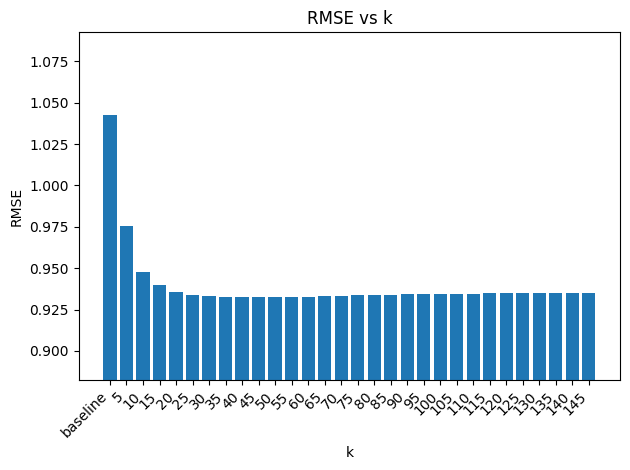

In [ ]:
k_list_str=[str(k) for k in k_list]
plt.bar(k_list_str,loss_list_rmse)
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("RMSE vs k")
plt.ylim((min(loss_list_rmse)-0.05),max(loss_list_rmse)+0.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

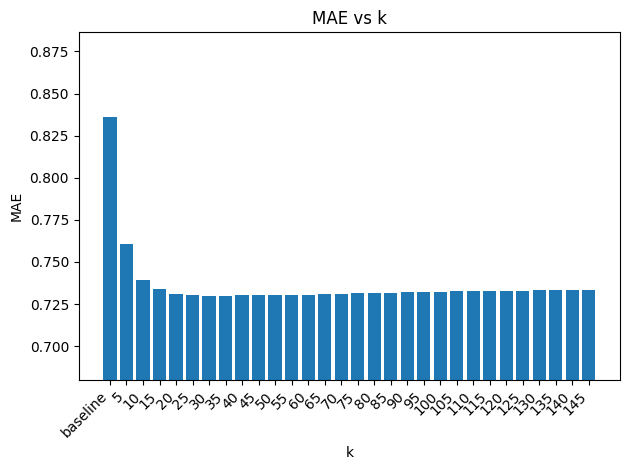

In [ ]:
k_list_str=[str(k) for k in k_list]
plt.bar(k_list_str,loss_list_mae)
plt.xlabel("k")
plt.ylabel("MAE")
plt.title("MAE vs k")
plt.ylim((min(loss_list_mae)-0.05),max(loss_list_mae)+0.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
print("Best k:",best_k)
pred=user_mean[test_df["u"]]
rmse=np.sqrt(np.mean((test_df["rating"].values-pred)**2))
mae=np.mean(np.abs(test_df["rating"].values-pred))
print("RMSE Baseline :",rmse)
print("MAE Baseline :",mae)

print("Using the Test set")

loss_list_rmse=[]
loss_list_mae=[]
k_list=[best_k]
loss_list_rmse.append(rmse)
loss_list_mae.append(mae)
for k in k_list:
    rmse,mae=eval_rmse(test_df, k)
    loss_list_rmse.append(rmse)
    loss_list_mae.append(mae)
    print(f"for k ={k}, RMSE = {rmse}")
k_list=["baseline"]+k_list

Best k: 40
RMSE Baseline : 1.0462482645703342
MAE Baseline : 0.8373842731366331
Using the Test set
for k =40, RMSE = 0.9458028847550279


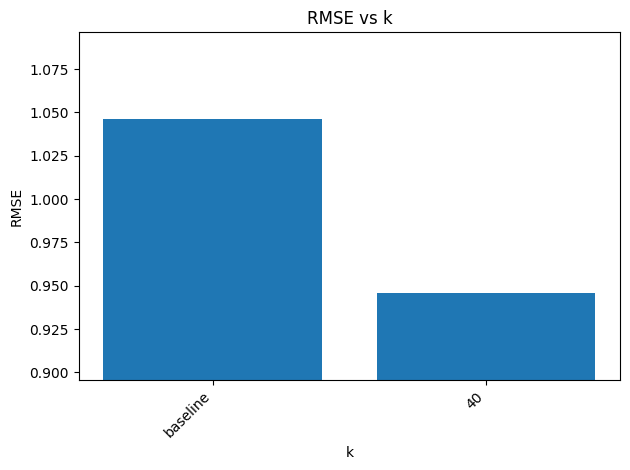

In [ ]:
k_list_str=[str(k) for k in k_list]
plt.bar(k_list_str,loss_list_rmse)
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("RMSE vs k")
plt.ylim((min(loss_list_rmse)-0.05),max(loss_list_rmse)+0.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

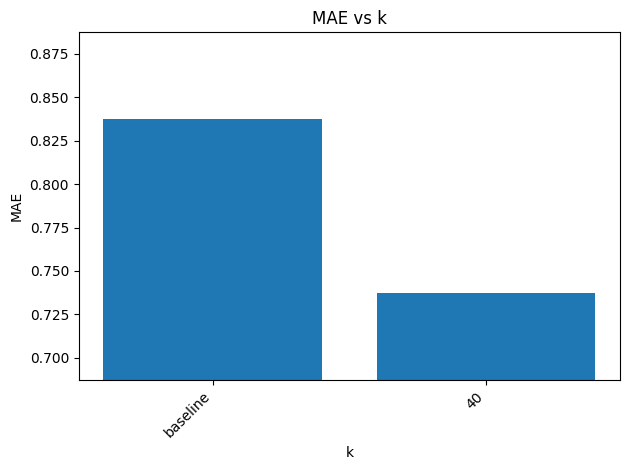

In [ ]:
k_list_str=[str(k) for k in k_list]
plt.bar(k_list_str,loss_list_mae)
plt.xlabel("k")
plt.ylabel("MAE")
plt.title("MAE vs k")
plt.ylim((min(loss_list_mae)-0.05),max(loss_list_mae)+0.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
def predict_all(k, S, Rc, mask, user_mean):
    n_users, n_movies = Rc.shape
    P = np.tile(user_mean[:, None], (1, n_movies))
    for i in range(n_movies):
        V = np.where(mask[:, i])[0]
        if len(V) == 0:
            continue

        w = np.clip(S[:, V], 0, None)
        if k < len(V):
            kth = -np.sort(-w, axis=1)[:, k-1:k]
            w = np.where(w >= kth, w, 0)

        num = w @ Rc[V, i]
        den = w.sum(axis=1)
        P[:, i] += np.where(den > 0, num / np.maximum(den, 1e-9), 0)

    return np.clip(P, 1, 5)

In [ ]:
P = predict_all(best_k, S, R_train_centre, mask, user_mean)

row = val_df.iloc[0]
print(P[row["u"], row["m"]],
      predict_user(row["u"], row["m"], best_k, S, R_train_centre, mask, user_mean))

4.444296326753099 4.4442963267531


In [ ]:
t0 = time.time()
P = predict_all(best_k, S, R_train_centre, mask, user_mean)
print("time:", time.time() - t0)

pred = P[test_df["u"].values, test_df["m"].values]
err = test_df["rating"].values - pred
print("Test RMSE:", np.sqrt(np.mean(err**2)), " MAE:", np.mean(np.abs(err)))

time: 2.352259635925293
Test RMSE: 0.9458031618185468  MAE: 0.7374037831116262


#  Model-based collaborative filtering

## Underlying Theory:

### User-Item description embedding
- Each User and item gets a vector of f dimensions presenting its latent features .

$$p_u \in \mathbb{R}^f$$  
$$q_i \in \mathbb{R}^f$$  
(where $P \in \mathbb{R}^{n_{\text{users}} \times f}$ and $Q \in \mathbb{R}^{n_{\text{items}} \times f}$)

- Here p and q are vectors of users and items respectively.
- P and Q are the stacked vectors of p and q respectively.
- We try to learn the following :
$$R=PQ^T$$
- where like before we get:
$$\hat r_{ui} = \mu + b_u + b_i + p_u \cdot q_i$$
- where
$\mu$ is the global mean rating,
$b_u$ is how generous user $u$ is relative to average. It plays the same role as centering with user_mean in kNN.
$b_i$ is how well liked movie $i$ is in general, such as a classic that nearly everyone rates highly.
$p_u \cdot q_i$ is the personalized interaction, whatever is left after the biases.

### Loss function:
- The Loss function used:
$$\mathcal L = \sum_{(u,i)\in \text{train}} \big(r_{ui}-\hat r_{ui}\big)^2 + \lambda\big(\|p_u\|^2+\|q_i\|^2+b_u^2+b_i^2\big)$$

### Stochastic Gradient descent:
- For instance, the gradient w.r.t. to $p_u$ is:
$$\frac{\partial}{\partial p_u} = -2e\,q_i + 2\lambda p_u$$
where $e_{ui} = r_{ui} - \hat r_{ui}$

- Therefore, the update rules become:
$$p_u \leftarrow p_u + \eta\,(e\,q_i - \lambda p_u)$$
$$q_i \leftarrow q_i + \eta\,(e\,p_u - \lambda q_i)$$
$$b_u \leftarrow b_u + \eta\,(e - \lambda b_u)$$
$$b_i \leftarrow b_i + \eta\,(e - \lambda b_i)$$

## From scratch Implementation

In [ ]:
def train_model(train,val,n_users,n_movies,f=30,lr=0.001,epochs=100,reg=0.005,seed=42,verbose=True):
  rng=np.random.default_rng(seed)

  P=rng.standard_normal((n_users,f))
  Q=rng.standard_normal((n_movies,f))

  us=train["u"].values
  ms=train["m"].values
  rs=train["rating"].values

  mu=rs.mean()
  bu=np.zeros(n_users)
  bm=np.zeros(n_movies)

  history={"train": [], "val": []}

  best_params={"val_error":np.inf,"train_error": np.inf}


  def predict(u,i):
    rating=mu+bu[u]+bm[i]+(P[u]*Q[i]).sum(axis=-1)
    return np.clip(rating,1,5)
  def rmse(d):
    e=predict(d["u"],d["m"])-d["rating"]
    return np.sqrt((e**2).mean())
  for epoch in range(epochs):

    for idx in rng.permutation(len(rs)):
      u,m,r=us[idx],ms[idx],rs[idx]
      e=r-predict(u,m)
      pu=P[u].copy()
      # Updation
      bu[u]+=lr*(e-reg*bu[u])
      bm[m]+=lr*(e-reg*bm[m])
      P[u]+=lr*(e*Q[m]-reg*pu)
      Q[m]+=lr*(e*pu-reg*Q[m])
    train_loss=rmse(train)
    val_loss=rmse(val)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    if(val_loss<best_params["val_error"]):
      best_params["val_error"]=val_loss
      best_params["train_error"]=train_loss
      best_params["P"]=P.copy()
      best_params["Q"]=Q.copy()
      best_params["bu"]=bu.copy()
      best_params["bm"]=bm.copy()
      best_params["mu"]=mu.copy()
      best_params["epoch"]=epoch
    if verbose:
      print(f"epoch: {epoch}| train_loss: {train_loss:.3f}| val_loss: {val_loss:.3f}")
  return best_params,history

In [ ]:
results_grid = {}
for f in [10, 20, 50]:
    for reg in [0.02, 0.05, 0.1]:
        b, h = train_model(train_df, val_df, n_users, n_movies, f=f, reg=reg, epochs=30,verbose=False)
        results_grid[(f, reg)] = b["val_error"]
        print(f"f={f} reg={reg} -> best val RMSE {b['val_error']:.4f}")

best_f, best_reg = min(results_grid, key=results_grid.get)
print("Best:", best_f, best_reg)

f=10 reg=0.02 -> best val RMSE 1.1537
f=10 reg=0.05 -> best val RMSE 1.1321
f=10 reg=0.1 -> best val RMSE 1.1010
f=20 reg=0.02 -> best val RMSE 1.3268
f=20 reg=0.05 -> best val RMSE 1.2864
f=20 reg=0.1 -> best val RMSE 1.2285
f=50 reg=0.02 -> best val RMSE 1.6915
f=50 reg=0.05 -> best val RMSE 1.6194
f=50 reg=0.1 -> best val RMSE 1.5099
Best: 10 0.1


In [ ]:
t0=time.time()
best_params,history=train_model(train_df,val_df,n_users,n_movies,f=best_f,reg=best_reg,epochs=100)
print("-"*20)
print("-"*20)
print("time:",time.time()-t0)
print("best epoch:",best_params["epoch"])
print("best train loss:",best_params["train_error"])
print("best val loss:",best_params["val_error"])
print("-"*20)
print("-"*20)


epoch: 0| train_loss: 2.088| val_loss: 2.117
epoch: 1| train_loss: 2.026| val_loss: 2.083
epoch: 2| train_loss: 1.963| val_loss: 2.049
epoch: 3| train_loss: 1.899| val_loss: 2.015
epoch: 4| train_loss: 1.838| val_loss: 1.981
epoch: 5| train_loss: 1.780| val_loss: 1.948
epoch: 6| train_loss: 1.723| val_loss: 1.916
epoch: 7| train_loss: 1.670| val_loss: 1.885
epoch: 8| train_loss: 1.620| val_loss: 1.857
epoch: 9| train_loss: 1.572| val_loss: 1.831
epoch: 10| train_loss: 1.528| val_loss: 1.807
epoch: 11| train_loss: 1.487| val_loss: 1.784
epoch: 12| train_loss: 1.448| val_loss: 1.762
epoch: 13| train_loss: 1.412| val_loss: 1.741
epoch: 14| train_loss: 1.378| val_loss: 1.721
epoch: 15| train_loss: 1.345| val_loss: 1.701
epoch: 16| train_loss: 1.315| val_loss: 1.683
epoch: 17| train_loss: 1.287| val_loss: 1.666
epoch: 18| train_loss: 1.260| val_loss: 1.651
epoch: 19| train_loss: 1.235| val_loss: 1.636
epoch: 20| train_loss: 1.211| val_loss: 1.622
epoch: 21| train_loss: 1.189| val_loss: 1.60

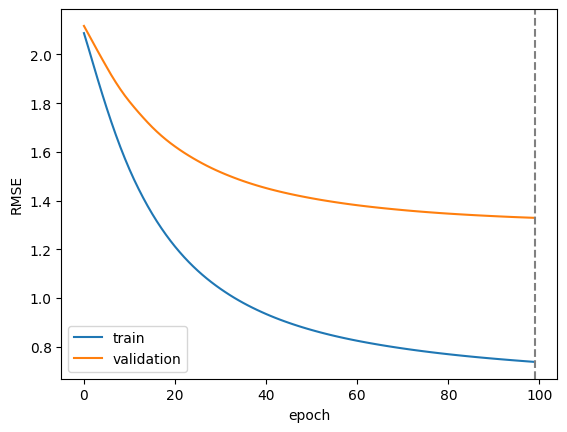

In [ ]:
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="validation")
plt.axvline(best_params["epoch"], ls="--", color="gray")
plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.legend()
plt.show()

## Conclusion